In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
dataset = pd.read_csv("Stress_Detection_Dataset.csv")
dataset.head()

,Unnamed: 0.1,Unnamed: 0,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress
0,1101,1887068,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,High
1,13705,3407329,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,Medium
2,9891,4010604,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low
3,7697,4110842,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low
4,1229,1634686,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,High


In [31]:
dataset.shape

(225000, 11)

In [32]:
dataset.drop(columns=["Unnamed: 0" ,"Unnamed: 0.1"] , inplace= True)

In [5]:
data_info = {
    "Shape": dataset.shape,
    "Columns": dataset.columns.tolist(),
    "Data Types": dataset.dtypes,
    "Missing Values": dataset.isnull().sum(),
    "Summary": dataset.describe()
}


In [6]:
data_info

{'Shape': (225000, 9),
 'Columns': ['X', 'Y', 'Z', 'TEMP', 'EDA', 'ECG', 'EMG', 'RESP', 'Stress'],
 'Data Types': X         float64
 Y         float64
 Z         float64
 TEMP      float64
 EDA       float64
 ECG       float64
 EMG       float64
 RESP      float64
 Stress     object
 dtype: object,
 'Missing Values': X         0
 Y         0
 Z         0
 TEMP      0
 EDA       0
 ECG       0
 EMG       0
 RESP      0
 Stress    0
 dtype: int64,
 'Summary':                    X              Y              Z           TEMP  \
 count  225000.000000  225000.000000  225000.000000  225000.000000   
 mean        0.816646      -0.004196      -0.266615      33.607337   
 std         0.129467       0.072809       0.314513       1.107826   
 min         0.334200      -0.350600      -0.955800      31.270782   
 25%         0.760400      -0.035400      -0.467800      32.561493   
 50%         0.872800       0.008800      -0.254600      33.966125   
 75%         0.906000       0.033000       0.0120

In [6]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,High
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,Medium
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,High


In [8]:
dataset.shape

(225000, 9)

In [9]:
dataset.isnull().sum()

X         0
Y         0
Z         0
TEMP      0
EDA       0
ECG       0
EMG       0
RESP      0
Stress    0
dtype: int64

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225000 entries, 0 to 224999
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   X       225000 non-null  float64
 1   Y       225000 non-null  float64
 2   Z       225000 non-null  float64
 3   TEMP    225000 non-null  float64
 4   EDA     225000 non-null  float64
 5   ECG     225000 non-null  float64
 6   EMG     225000 non-null  float64
 7   RESP    225000 non-null  float64
 8   Stress  225000 non-null  object 
dtypes: float64(8), object(1)
memory usage: 15.4+ MB


In [11]:
dataset.describe()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP
count,225000.000000,225000.000000,225000.000000,225000.000000,225000.000000,225000.000000,225000.000000,225000.000000
mean,0.816646,-0.004196,-0.266615,33.607337,5.798486,-0.001085,-0.003175,0.032415
std,0.129467,0.072809,0.314513,1.107826,3.143063,0.272254,0.019906,4.058577
min,0.334200,-0.350600,-0.955800,31.270782,0.449371,-1.314606,-0.452957,-36.167908
25%,0.760400,-0.035400,-0.467800,32.561493,2.916622,-0.095627,-0.010025,-2.247620
50%,0.872800,0.008800,-0.254600,33.966125,6.477737,-0.028290,-0.002563,-0.242615
75%,0.906000,0.033000,0.012000,34.437714,8.147812,0.025589,0.003937,2.183533
max,1.303800,0.388600,0.732600,35.682922,13.466263,1.499496,0.358017,32.131958


In [12]:
dataset["Stress"].value_counts()

Stress
High      75000
Medium    75000
Low       75000
Name: count, dtype: int64

C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\82696821.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Stress", data=dataset, palette="coolwarm")


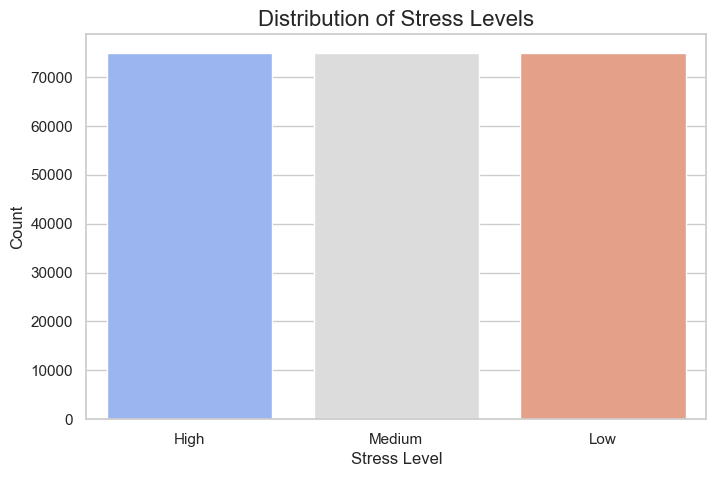

In [13]:
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.countplot(x="Stress", data=dataset, palette="coolwarm")
plt.title("Distribution of Stress Levels", fontsize=16)
plt.xlabel("Stress Level", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()



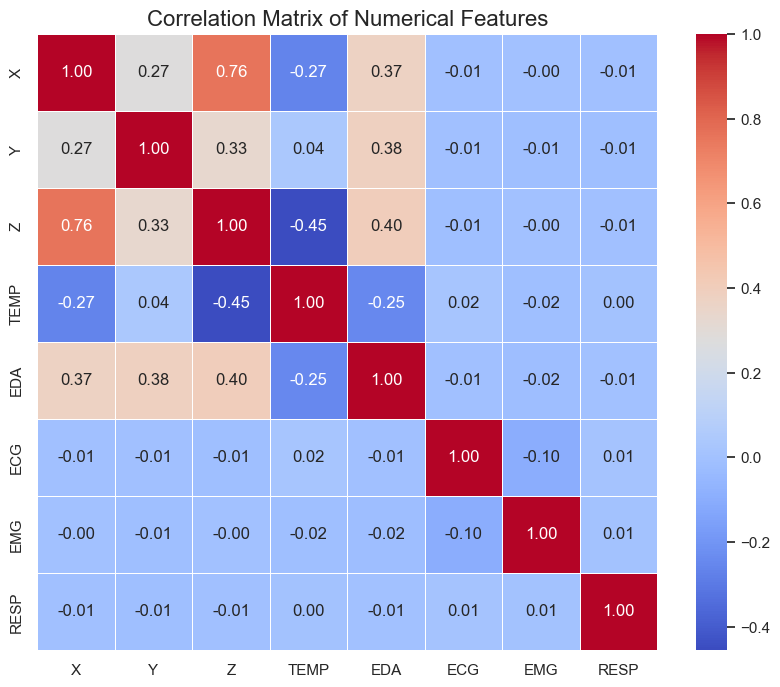

In [23]:
sns.set(style="whitegrid")
numerical_cols = ['X', 'Y', 'Z', 'TEMP', 'EDA', 'ECG', 'EMG', 'RESP']
correlation_matrix = dataset[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.savefig("corr.png")
plt.show()

C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\970423680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=dataset[col], palette="coolwarm")
C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\970423680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=dataset[col], palette="coolwarm")
C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\970423680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=dataset[col], palette="coolwarm")
C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\970423680.py:5: FutureWarning: 

Passing `palette` withou

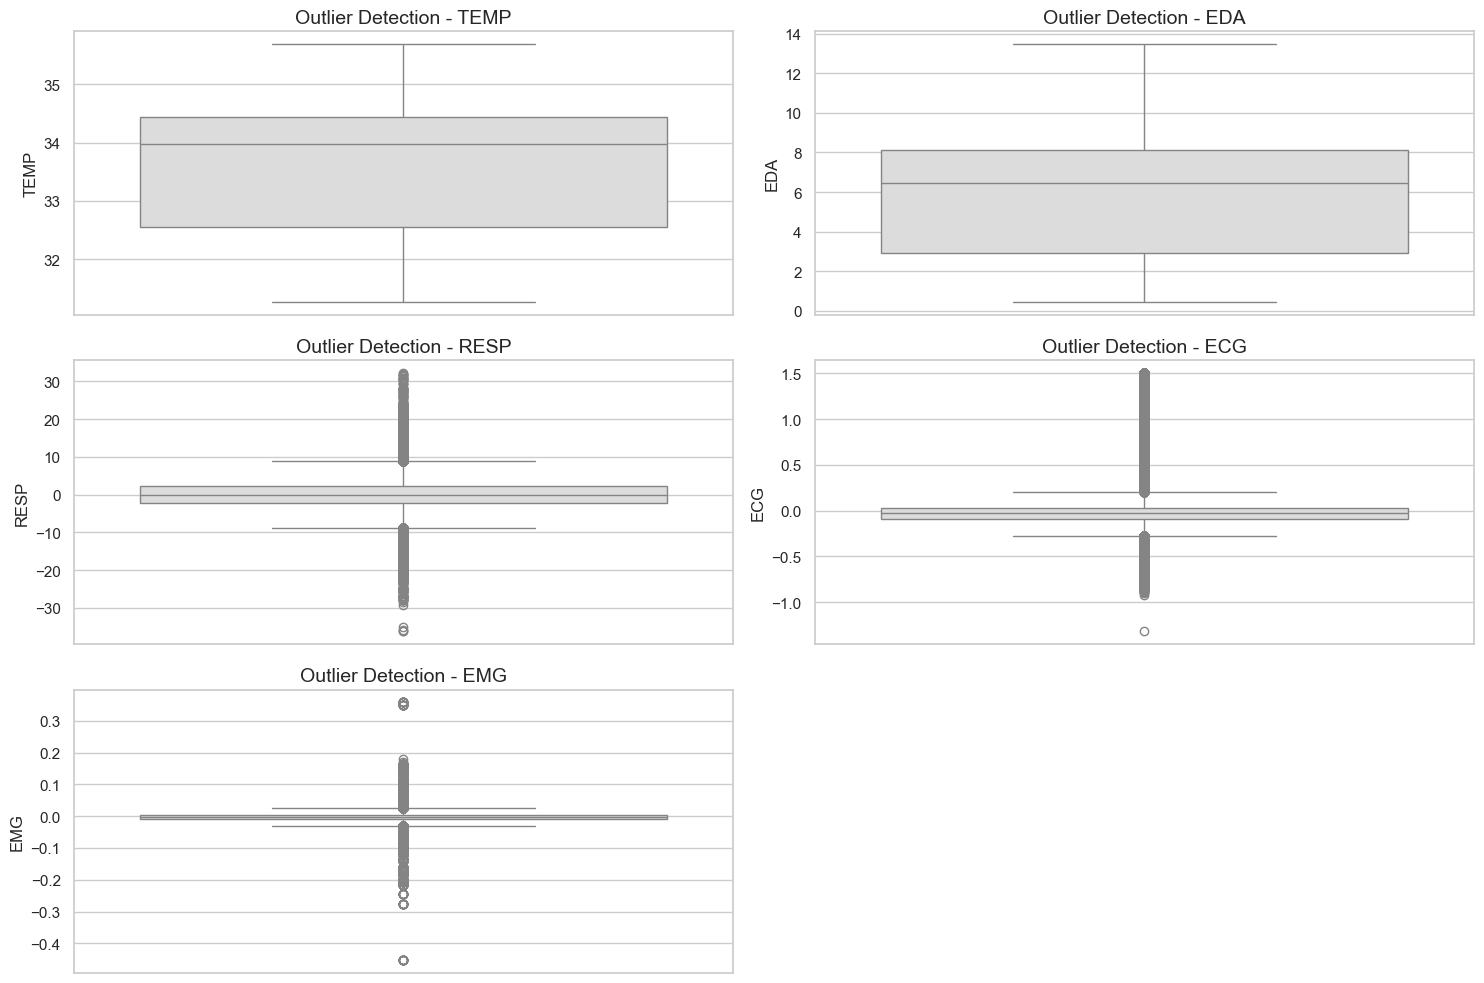

In [15]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))
for i, col in enumerate(['TEMP', 'EDA', 'RESP', 'ECG', 'EMG'], 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=dataset[col], palette="coolwarm")
    plt.title(f"Outlier Detection - {col}", fontsize=14)
    plt.ylabel(col, fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\851979716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Stress', y=col, data=dataset, palette="coolwarm")
C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\851979716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Stress', y=col, data=dataset, palette="coolwarm")
C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\851979716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Stress', y=col, data=dataset, palette="coolwarm")


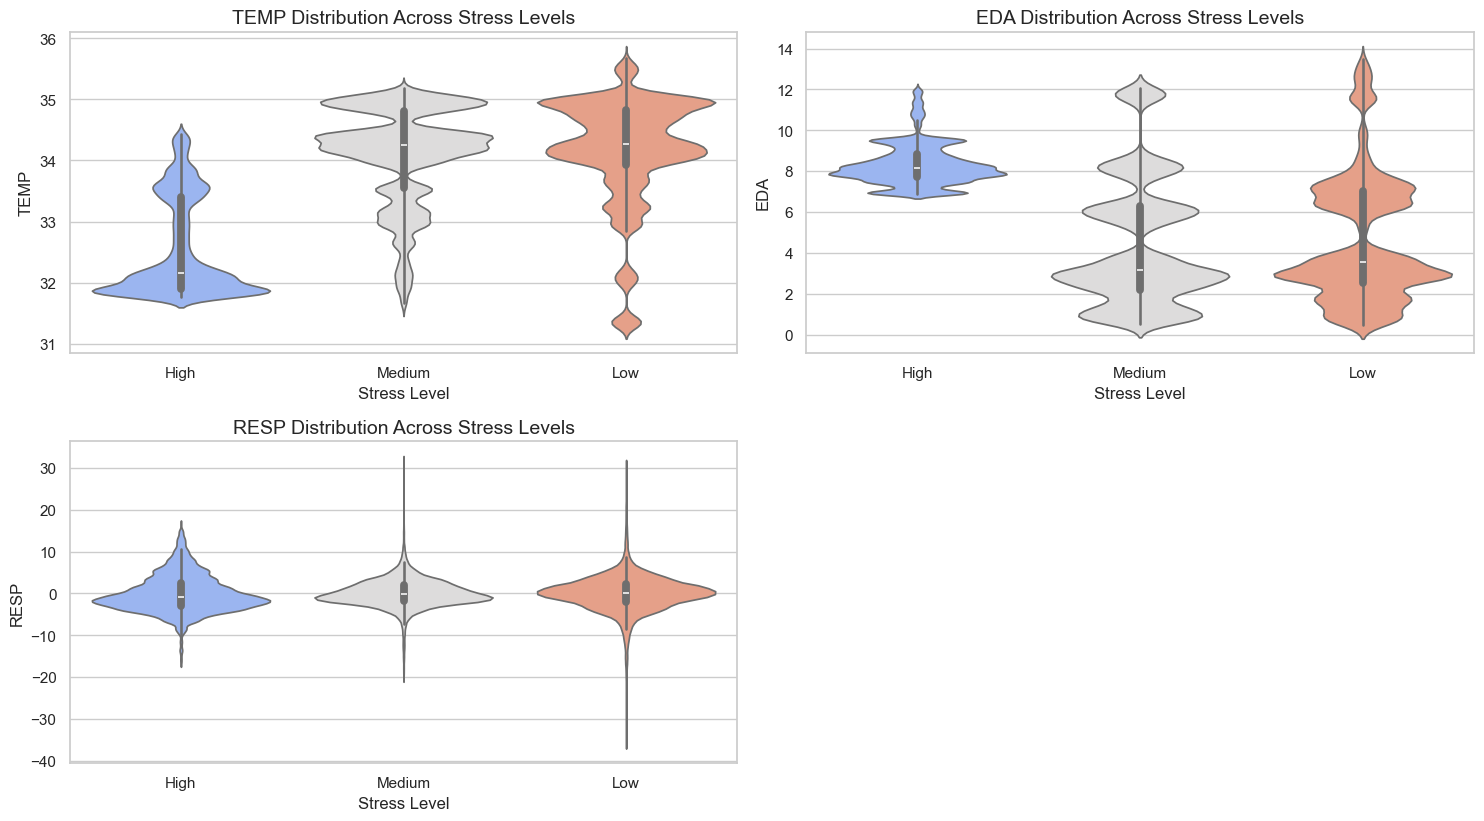

In [16]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 12))
for i, col in enumerate(['TEMP', 'EDA', 'RESP'], 1):
    plt.subplot(3, 2, i)
    sns.violinplot(x='Stress', y=col, data=dataset, palette="coolwarm")
    plt.title(f"{col} Distribution Across Stress Levels", fontsize=14)
    plt.xlabel("Stress Level", fontsize=12)
    plt.ylabel(col, fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\shabi\AppData\Local\Temp\ipykernel_6388\3112927696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stress_distribution.index, y=stress_distribution.values, palette="coolwarm")


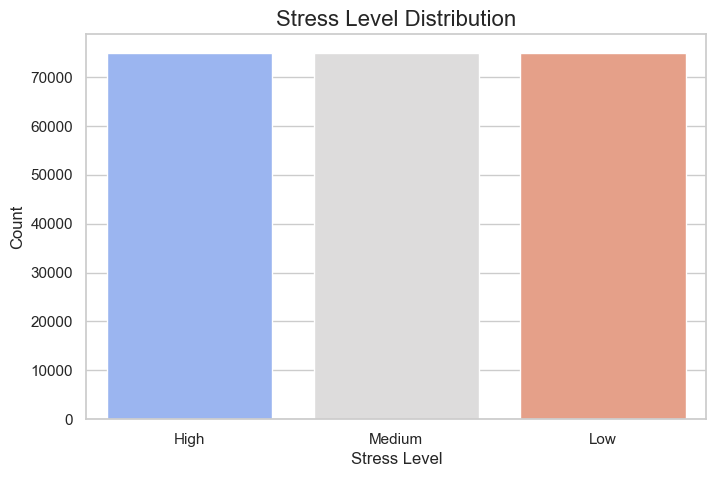

In [17]:
stress_distribution = dataset['Stress'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=stress_distribution.index, y=stress_distribution.values, palette="coolwarm")
plt.title("Stress Level Distribution", fontsize=16)
plt.xlabel("Stress Level", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

C:\Users\shabi\AppData\Local\Temp\ipykernel_7076\670168706.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_correlation.index, y=feature_correlation.values, palette="coolwarm")


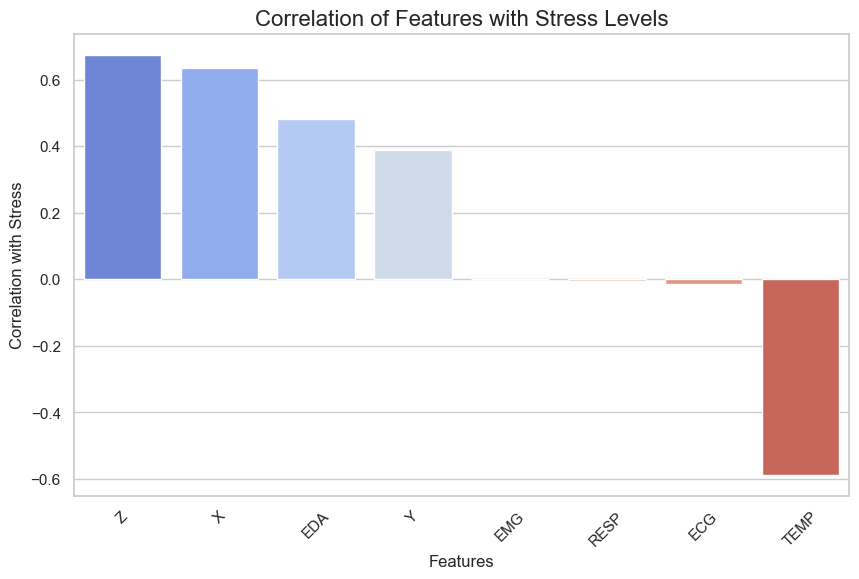

Z       0.675263
X       0.635917
EDA     0.480972
Y       0.388765
EMG    -0.000704
RESP   -0.006272
ECG    -0.013951
TEMP   -0.587140
Name: Stress, dtype: float64

In [38]:
data_encoded = dataset.copy()
stress_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data_encoded['Stress'] = data_encoded['Stress'].map(stress_mapping)


feature_correlation = data_encoded.corr()['Stress'].drop('Stress').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_correlation.index, y=feature_correlation.values, palette="coolwarm")
plt.title("Correlation of Features with Stress Levels", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Correlation with Stress", fontsize=12)
plt.xticks(rotation=45)
plt.savefig("cor_stress30.png")
plt.show()

feature_correlation

In [19]:
numerical_features = ['TEMP', 'EDA', 'RESP', 'ECG', 'EMG']

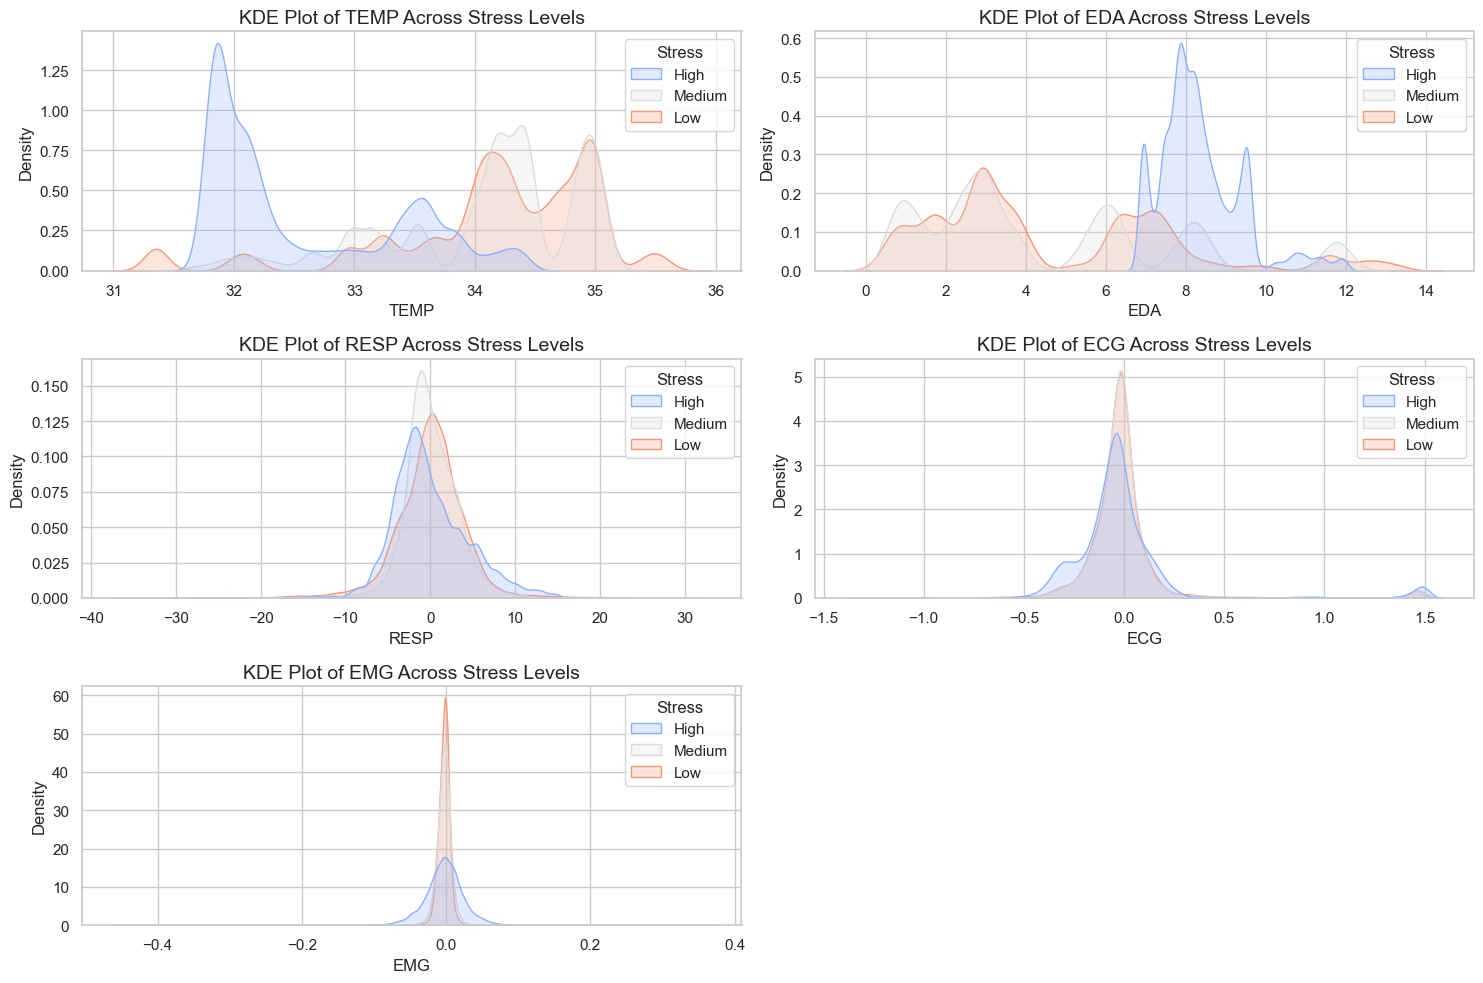

In [20]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(data=dataset, x=col, hue='Stress', fill=True, common_norm=False, palette="coolwarm")
    plt.title(f"KDE Plot of {col} Across Stress Levels", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Density", fontsize=12)
plt.tight_layout()
plt.show()

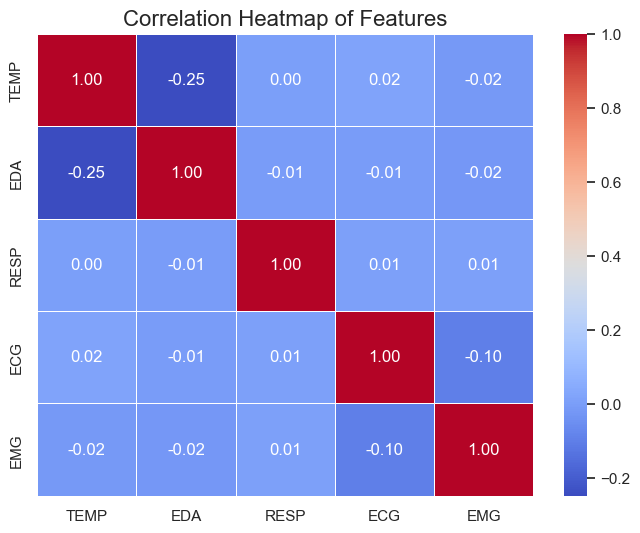

In [21]:
corr_matrix = dataset[numerical_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features", fontsize=16)
plt.show()

In [22]:
from scipy.stats import zscore


z_scores = dataset[numerical_features].apply(zscore)

outliers = (z_scores.abs() > 3).sum()
print("Outliers in each feature based on Z-score:")
print(outliers)

Outliers in each feature based on Z-score:
TEMP       0
EDA        0
RESP    3567
ECG     6488
EMG     3786
dtype: int64


In [23]:
from scipy.stats import f_oneway

# Perform ANOVA for each feature
for col in numerical_features:
    groups = [dataset[dataset['Stress'] == level][col] for level in dataset['Stress'].unique()]
    f_stat, p_val = f_oneway(*groups)
    print(f"{col} - ANOVA Test: p-value = {p_val}")

TEMP - ANOVA Test: p-value = 0.0
EDA - ANOVA Test: p-value = 0.0
RESP - ANOVA Test: p-value = 6.0390756346078205e-05
ECG - ANOVA Test: p-value = 1.0874919682951563e-13
EMG - ANOVA Test: p-value = 0.44017704048309925


In [24]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis test for each feature
for col in numerical_features:
    groups = [dataset[dataset['Stress'] == level][col] for level in dataset['Stress'].unique()]
    h_stat, p_val = kruskal(*groups)
    print(f"{col} - Kruskal-Wallis Test: p-value = {p_val}")

TEMP - Kruskal-Wallis Test: p-value = 0.0
EDA - Kruskal-Wallis Test: p-value = 0.0
RESP - Kruskal-Wallis Test: p-value = 3.747743696162682e-205
ECG - Kruskal-Wallis Test: p-value = 0.0
EMG - Kruskal-Wallis Test: p-value = 6.3380527107652014e-15


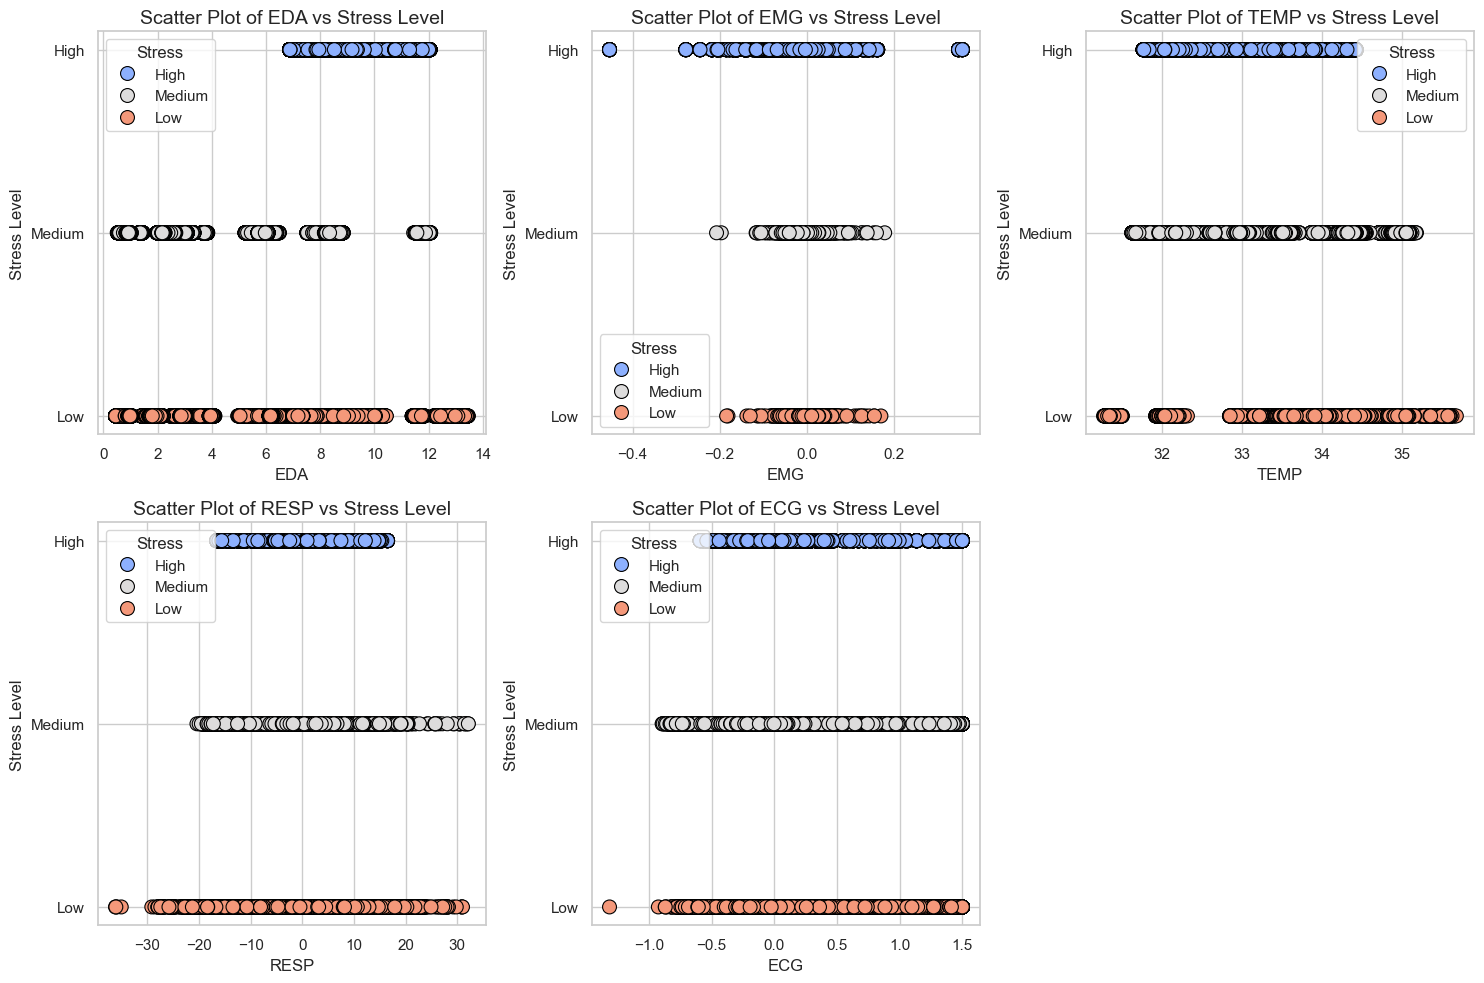

In [25]:
# Features to plot
features = ['EDA', 'EMG', 'TEMP', 'RESP' , "ECG"]

# Create scatter plots for each feature with Stress as hue
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=dataset, x=feature, y='Stress', hue='Stress', palette='coolwarm', s=100, edgecolor='black')
    plt.title(f'Scatter Plot of {feature} vs Stress Level', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Stress Level', fontsize=12)
plt.tight_layout()
plt.show()

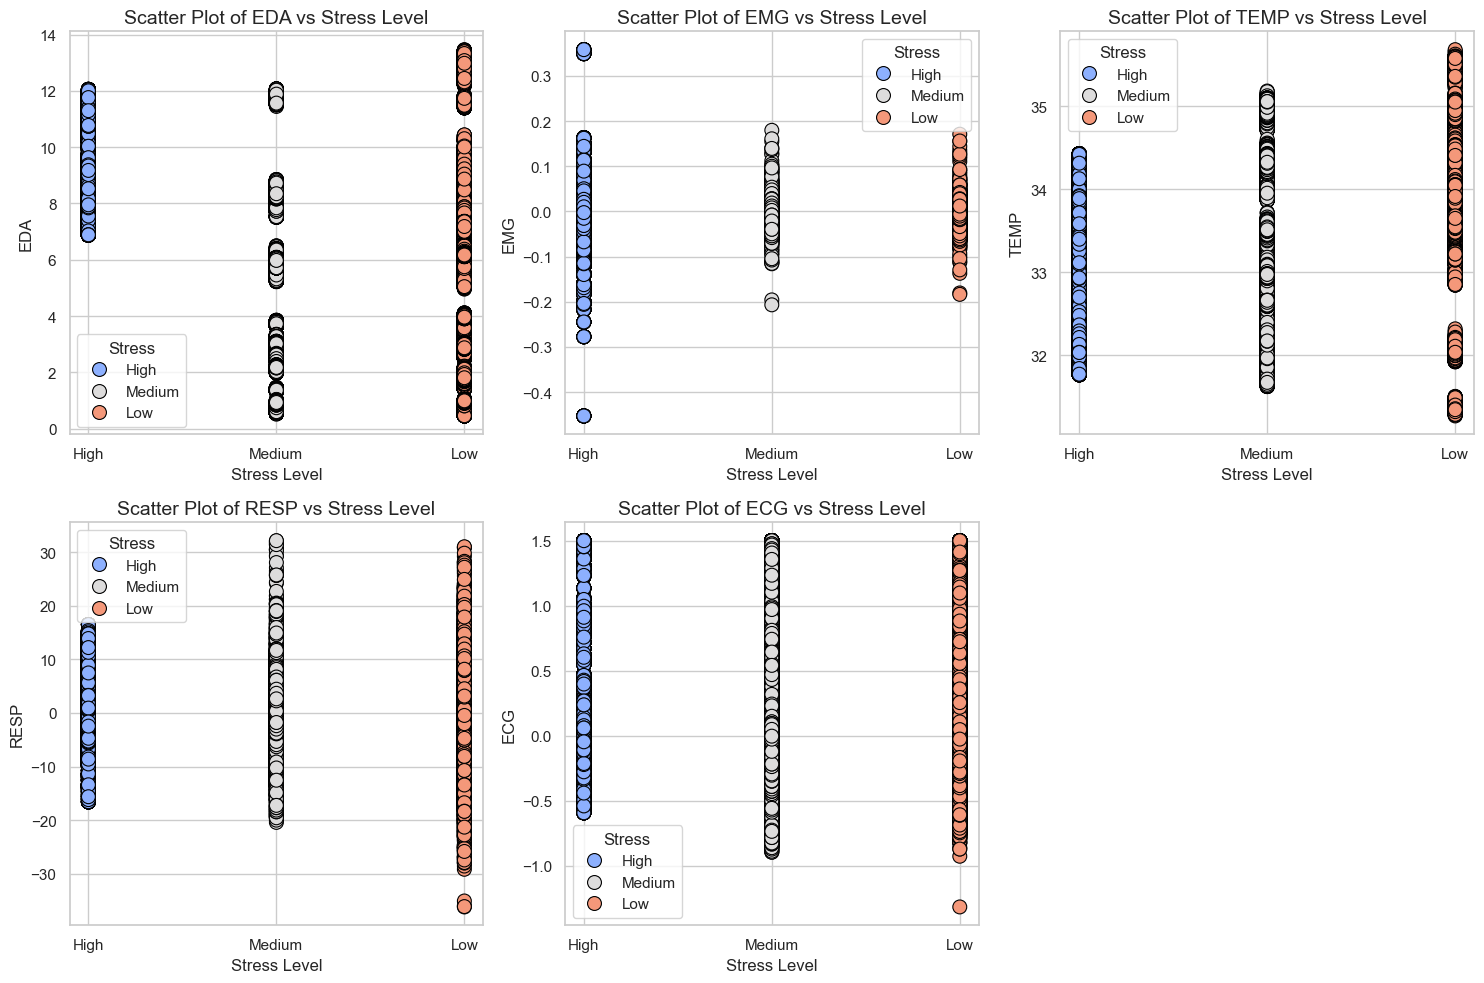

In [26]:
# Features to plot
features = ['EDA', 'EMG', 'TEMP', 'RESP' , "ECG"]

# Create scatter plots for each feature with Stress as hue
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=dataset, x='Stress', y=feature, hue='Stress', palette='coolwarm', s=100, edgecolor='black')
    plt.title(f'Scatter Plot of {feature} vs Stress Level', fontsize=14)
    plt.xlabel('Stress Level', fontsize=12)
    plt.ylabel(feature, fontsize=12)
plt.tight_layout()
plt.show()

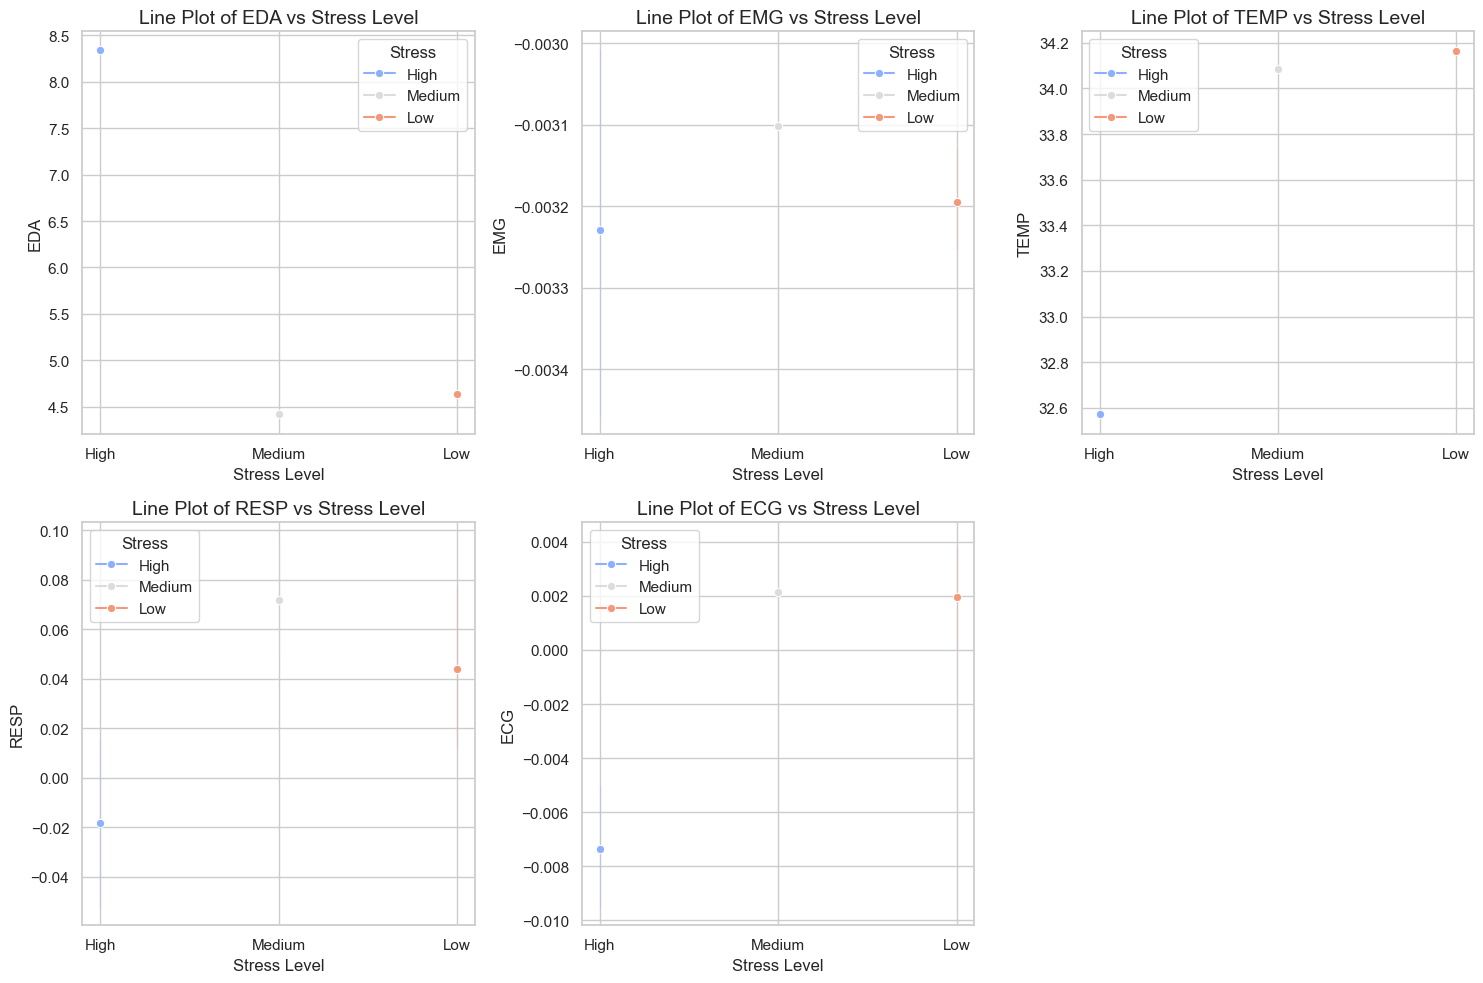

In [27]:
features = ['EDA', 'EMG', 'TEMP', 'RESP' , "ECG"]

# Create line plots for each feature with Stress as hue
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.lineplot(data=dataset, x='Stress', y=feature, hue='Stress', palette='coolwarm', marker='o')
    plt.title(f'Line Plot of {feature} vs Stress Level', fontsize=14)
    plt.xlabel('Stress Level', fontsize=12)
    plt.ylabel(feature, fontsize=12)
plt.tight_layout()
plt.show()

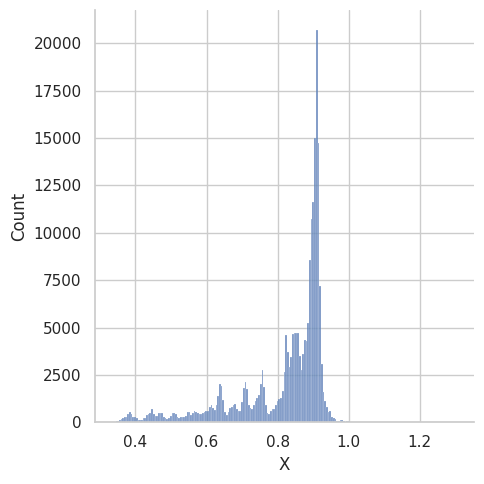

In [89]:
sns.displot(dataset["X"])

<Axes: ylabel='X'>

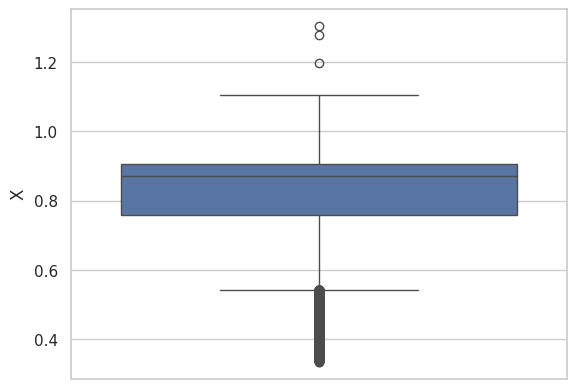

In [90]:
sns.boxplot(dataset["X"])

<Axes: ylabel='X'>

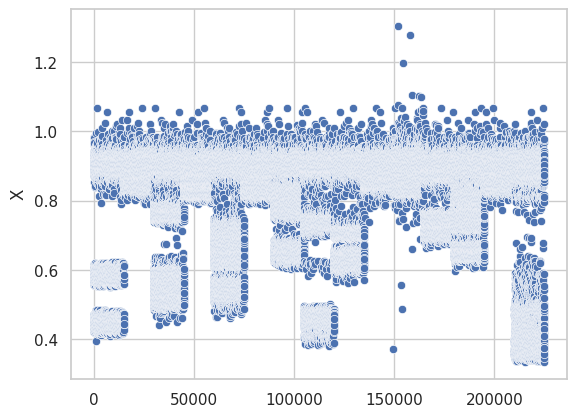

In [91]:
sns.scatterplot(dataset["X"])

In [92]:
q1 = dataset["X"].quantile(0.25)
q3 = dataset["X"].quantile(0.75)

IQR = q3 - q1


min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)

print(min_range)
print(max_range)

0.5420001149177551
1.1243999600410461


In [93]:
dataset[dataset["X"] < 0.54]

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress,RESP_scaled,Stress_numeric
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low,0.545207,0
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low,0.572641,0
10,0.4494,-0.2430,-0.8414,32.082000,0.564957,-0.010437,-0.003983,-0.798035,Low,0.517862,0
13,0.4548,-0.2430,-0.8370,32.153260,0.615311,0.033005,0.000412,-1.885986,Low,0.501932,0
20,0.4694,-0.2504,-0.8206,32.187470,0.669479,0.114853,0.004715,-1.039124,Low,0.514332,0
...,...,...,...,...,...,...,...,...,...,...,...
224977,0.4424,0.0264,-0.8702,33.934204,7.149124,-0.068665,-0.008011,3.150940,Low,0.575680,0
224978,0.4304,0.0212,-0.8594,34.023956,7.060242,0.723312,-0.003983,7.981873,Low,0.646411,0
224983,0.4084,0.0190,-0.8778,34.048340,7.009506,0.255203,-0.010574,-0.462341,Low,0.522777,0
224987,0.4956,0.0408,-0.8086,33.914430,7.181168,-0.166306,-0.006226,-4.730225,Low,0.460289,0


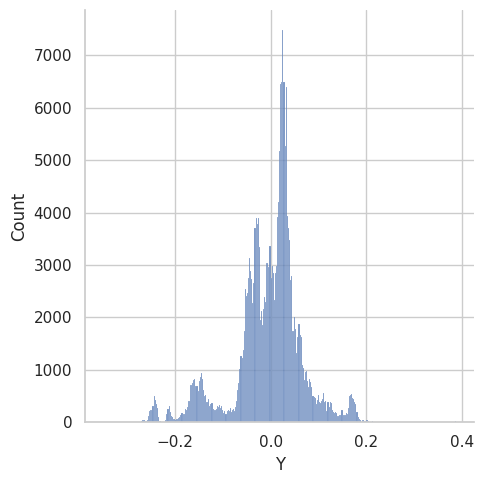

In [94]:
sns.displot(dataset["Y"])

<Axes: ylabel='X'>

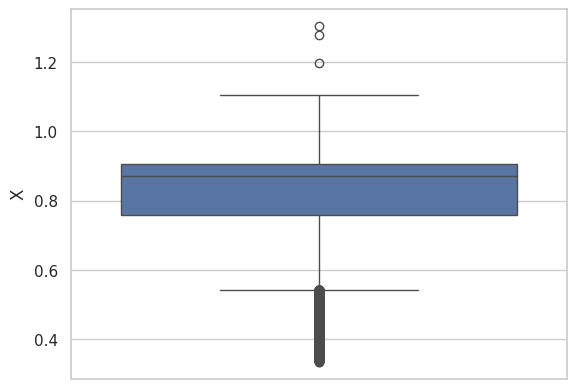

In [95]:
sns.boxplot(dataset["X"])

<Axes: ylabel='X'>

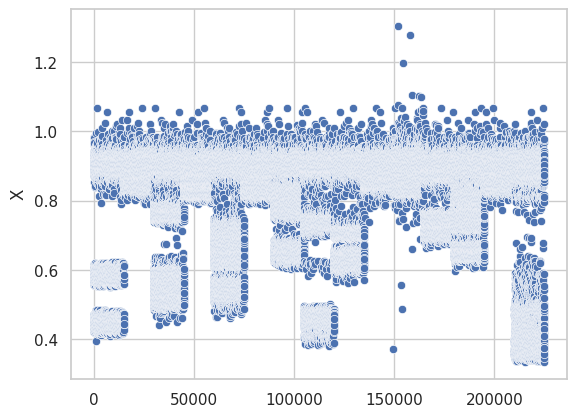

In [96]:
sns.scatterplot(dataset["X"])

In [97]:
q1 = dataset["Y"].quantile(0.25)
q3 = dataset["Y"].quantile(0.75)

IQR = q3 - q1


min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)

print(min_range)
print(max_range)

-0.13799992203712436
0.13559994101524325


<Axes: ylabel='Z'>

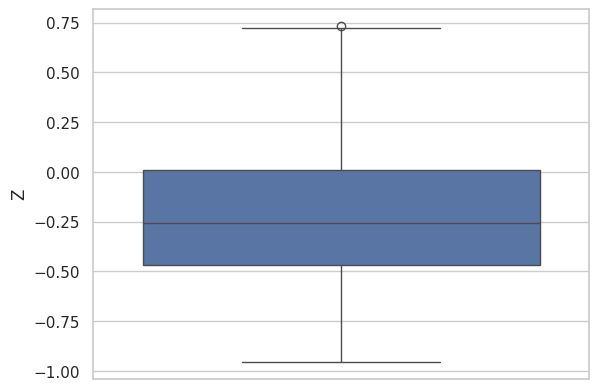

In [98]:
sns.boxplot(dataset["Z"])

<Axes: ylabel='Z'>

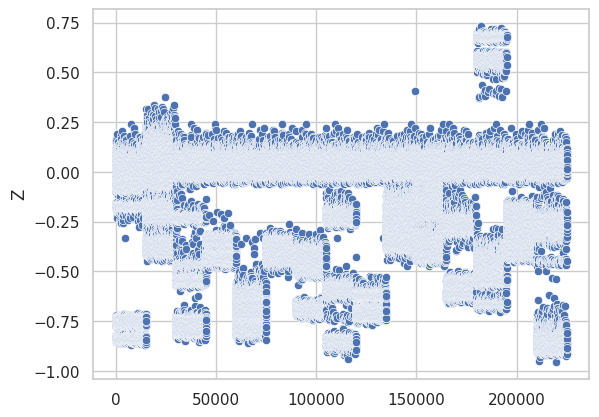

In [99]:
sns.scatterplot(dataset["Z"])

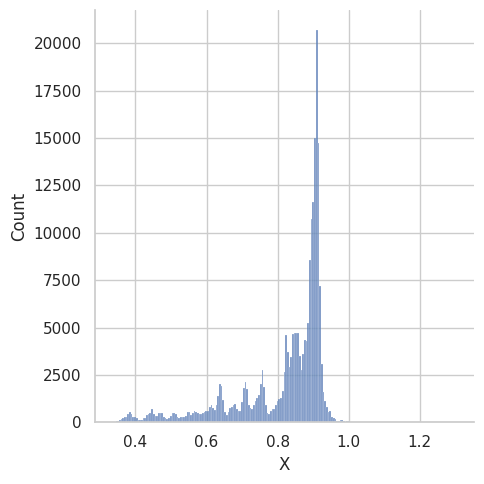

In [100]:
sns.displot(dataset["X"])

In [101]:
q1 = dataset["Z"].quantile(0.25)
q3 = dataset["Z"].quantile(0.75)

IQR = q3 - q1


min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)

print(min_range)
print(max_range)

-1.1874999999999998
0.7316999435424801


In [102]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress,RESP_scaled,Stress_numeric
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,High,0.489958,2
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,Medium,0.496571,1
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low,0.545207,0
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low,0.572641,0
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,High,0.518509,2


<Axes: ylabel='TEMP'>

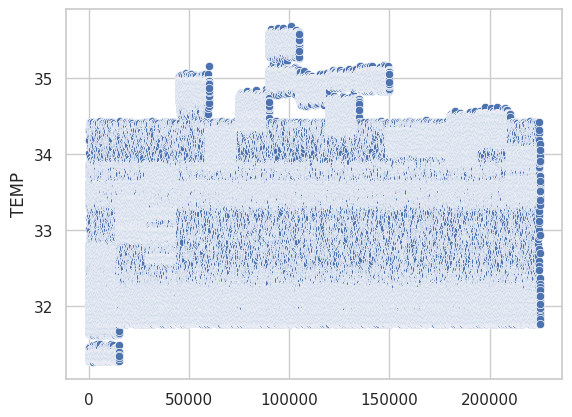

In [103]:
sns.scatterplot(dataset["TEMP"])

<Axes: ylabel='TEMP'>

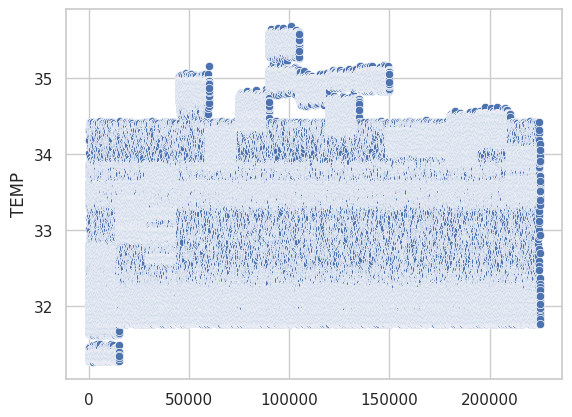

In [104]:
sns.scatterplot(dataset["TEMP"])

<Axes: ylabel='TEMP'>

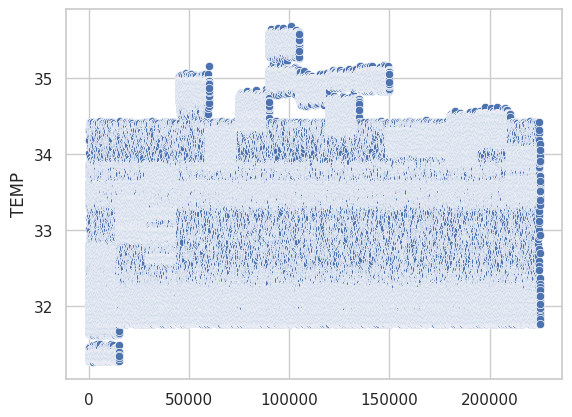

In [105]:
sns.scatterplot(dataset["TEMP"])

In [106]:
q1 = dataset["TEMP"].quantile(0.25)
q3 = dataset["TEMP"].quantile(0.75)

IQR = q3 - q1


min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)

print(min_range)
print(max_range)

29.747161499999997
37.2520455


In [107]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress,RESP_scaled,Stress_numeric
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,High,0.489958,2
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,Medium,0.496571,1
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low,0.545207,0
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low,0.572641,0
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,High,0.518509,2


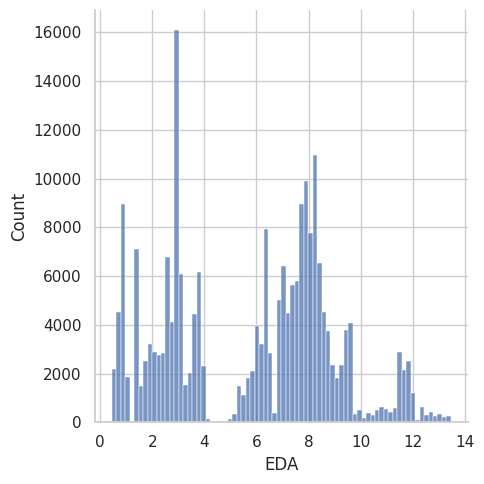

In [108]:
sns.displot(dataset["EDA"])

<Axes: ylabel='EDA'>

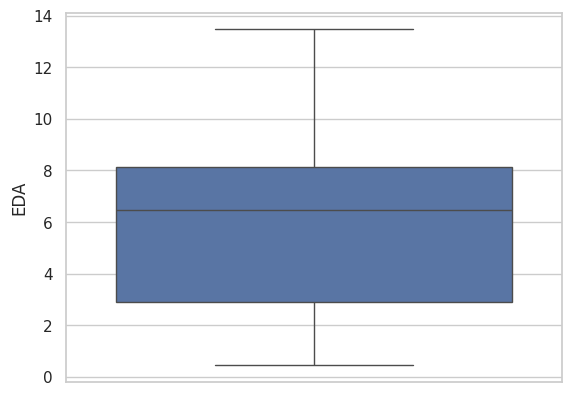

In [109]:
sns.boxplot(dataset["EDA"])

<Axes: ylabel='EDA'>

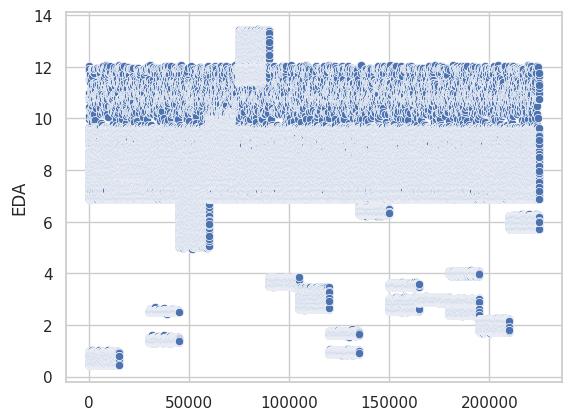

In [110]:
sns.scatterplot(dataset["EDA"])

In [111]:
q1 = dataset["EDA"].quantile(0.25)
q3 = dataset["EDA"].quantile(0.75)

IQR = q3 - q1


min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)

print(min_range)
print(max_range)

-4.93016242980957
15.994596481323242


In [112]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress,RESP_scaled,Stress_numeric
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,High,0.489958,2
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,Medium,0.496571,1
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low,0.545207,0
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low,0.572641,0
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,High,0.518509,2


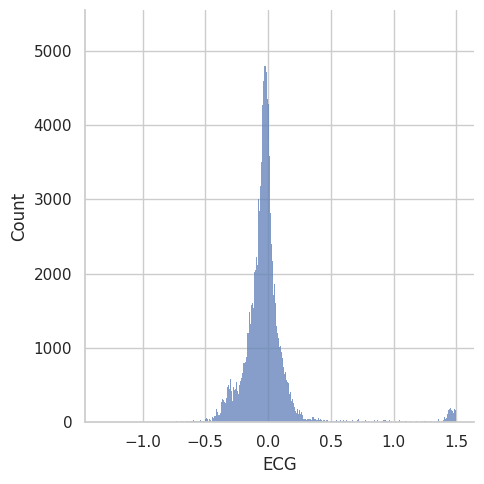

In [113]:
sns.displot(dataset["ECG"])

<Axes: ylabel='ECG'>

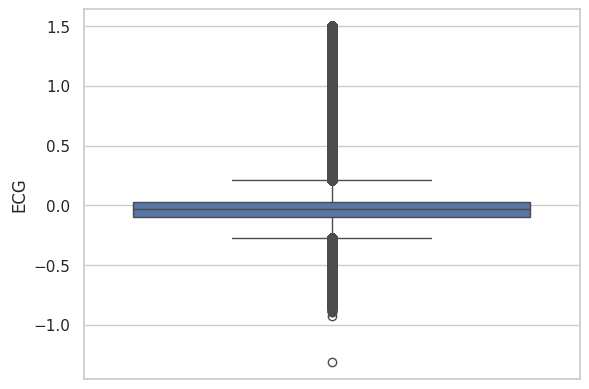

In [114]:
sns.boxplot(dataset["ECG"])

<Axes: ylabel='ECG'>

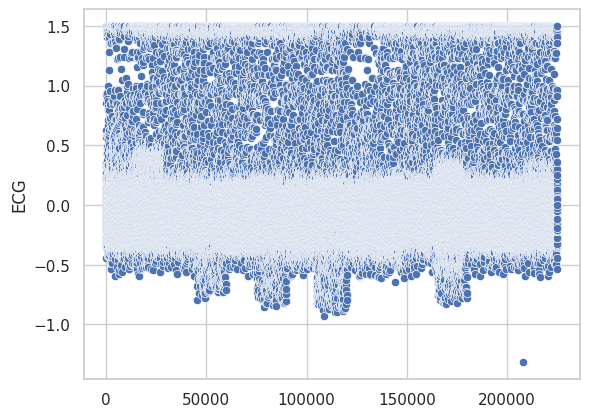

In [115]:
sns.scatterplot(dataset["ECG"])

In [116]:
q1 = dataset["ECG"].quantile(0.25)
q3 = dataset["ECG"].quantile(0.75)

IQR = q3 - q1


min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)

print(min_range)
print(max_range)

-0.2774505615234375
0.2074127197265625


In [117]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress,RESP_scaled,Stress_numeric
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,High,0.489958,2
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,Medium,0.496571,1
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low,0.545207,0
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low,0.572641,0
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,High,0.518509,2


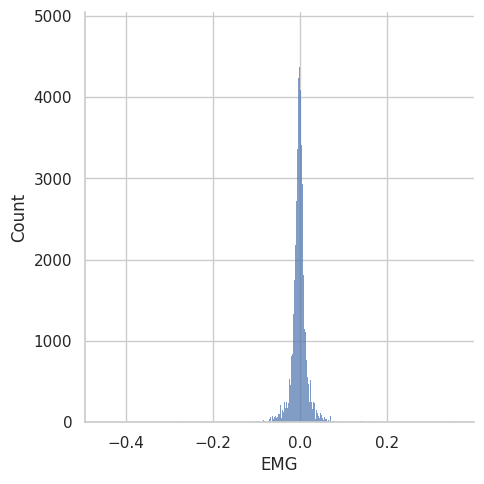

In [118]:
sns.displot(dataset["EMG"])

<Axes: ylabel='EMG'>

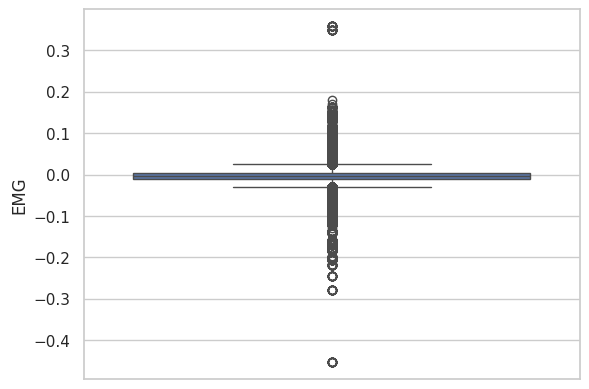

In [119]:
sns.boxplot(dataset["EMG"])

<Axes: ylabel='EMG'>

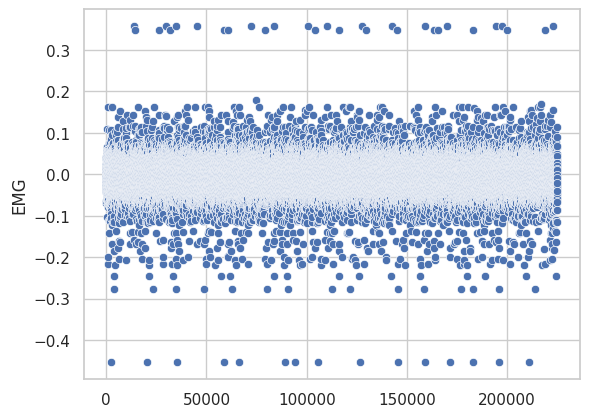

In [120]:
sns.scatterplot(dataset["EMG"])

In [121]:
q1 = dataset["EMG"].quantile(0.25)
q3 = dataset["EMG"].quantile(0.75)

IQR = q3 - q1


min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)

print(min_range)
print(max_range)

-0.03096771240234375
0.02487945556640625


In [122]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress,RESP_scaled,Stress_numeric
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,High,0.489958,2
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,Medium,0.496571,1
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low,0.545207,0
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low,0.572641,0
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,High,0.518509,2


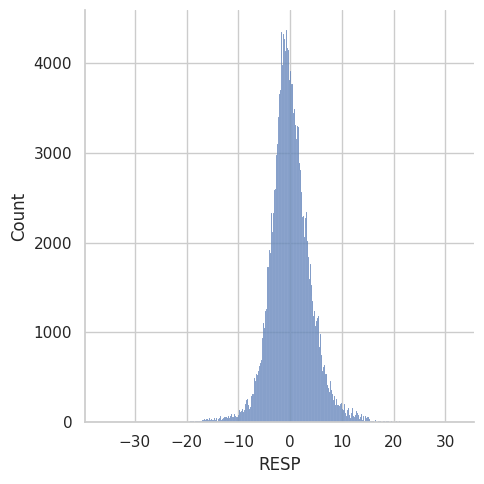

In [123]:
sns.displot(dataset["RESP"])

<Axes: ylabel='RESP'>

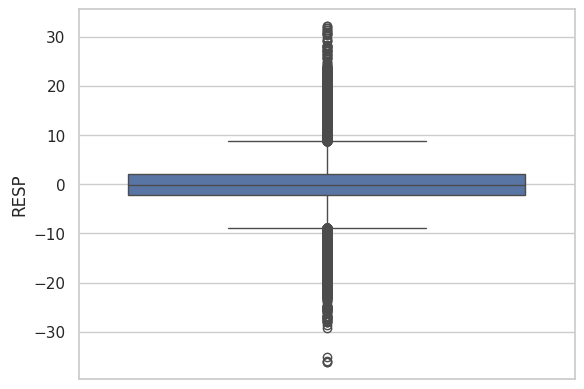

In [124]:
sns.boxplot(dataset["RESP"])

<Axes: ylabel='RESP'>

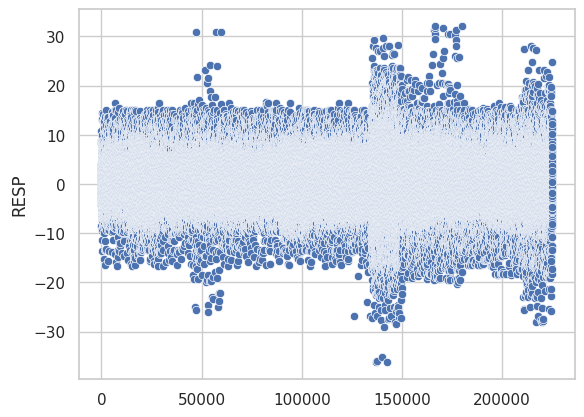

In [125]:
sns.scatterplot(dataset["RESP"])

In [126]:
q1 = dataset["RESP"].quantile(0.25)
q3 = dataset["RESP"].quantile(0.75)

IQR = q3 - q1


min_range = q1 - (1.5 * IQR)
max_range = q3 + (1.5 * IQR)

print(min_range)
print(max_range)

-8.89434814453125
8.83026123046875


In [127]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress,RESP_scaled,Stress_numeric
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,High,0.489958,2
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,Medium,0.496571,1
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,Low,0.545207,0
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,Low,0.572641,0
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,High,0.518509,2


In [128]:
#sns.pairplot(dataset , hue="Stress")

In [129]:
dataset["Stress"].value_counts()

,count
Stress,
High,75000
Medium,75000
Low,75000


In [25]:
def fetch_stress(x):
    if x == "High":
        return 3
    if x == "Medium":
        return 2
    return 1

In [26]:
dataset["Stress"] = dataset["Stress"].apply(fetch_stress)

In [27]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,3
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,2
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,1
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,1
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,3


In [154]:
dataset.drop(columns = ["RESP_scaled" , "Stress_numeric"] , inplace = True)

In [156]:
dataset.head()

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP,Stress
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857,3
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197,2
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641,1
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420,1
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784,3


In [157]:
dataset.corr()["Stress"]

,Stress
X,0.635917
Y,0.388765
Z,0.675263
TEMP,-0.587140
EDA,0.480972
ECG,-0.013951
EMG,-0.000704
RESP,-0.006272
Stress,1.000000


In [ ]:
sns.heatmap(dataset.corr() , annot = True)

<Axes: >

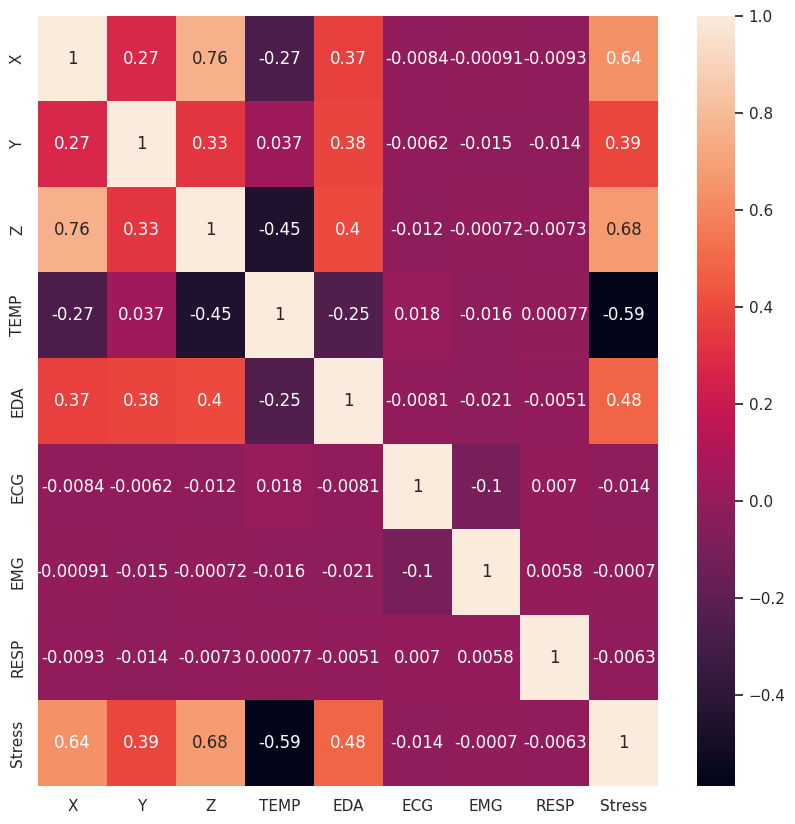

In [159]:
plt.figure(figsize=(10,10))
sns.heatmap(dataset.corr(numeric_only=True) , annot= True)

In [7]:
x = dataset.drop( columns= ["Stress"])
y =  (dataset["Stress"])

In [8]:
x

,X,Y,Z,TEMP,EDA,ECG,EMG,RESP
0,0.9050,0.0344,0.0418,31.889160,8.601761,-0.032547,0.013321,-2.703857
1,0.9138,-0.1422,-0.0694,32.227600,0.884628,0.020691,-0.004303,-2.252197
2,0.4426,-0.2440,-0.8464,32.010742,0.529099,0.079330,0.007462,1.069641
3,0.4248,-0.2466,-0.8498,31.936615,0.453949,-0.040970,-0.018173,2.943420
4,0.9326,0.0386,0.0030,32.217224,7.914734,-0.292007,-0.006729,-0.753784
...,...,...,...,...,...,...,...,...
224995,0.9146,0.0306,0.0108,31.773712,7.951355,-0.045959,0.010117,-2.450562
224996,0.9034,0.0406,0.0134,32.932770,10.773087,-0.439774,-0.002747,7.463074
224997,0.8838,-0.0250,-0.2646,33.547455,5.993271,-0.025314,-0.008240,2.632141
224998,0.8866,-0.0290,-0.2592,33.535340,6.023788,0.049530,-0.021378,-1.777649


In [9]:
y

0           High
1         Medium
2            Low
3            Low
4           High
           ...  
224995      High
224996      High
224997    Medium
224998    Medium
224999    Medium
Name: Stress, Length: 225000, dtype: object

In [10]:
print(x.shape)
print(y.shape)

(225000, 8)
(225000,)


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train , x_test , y_train , y_test = train_test_split( x , y , test_size= 0.2 , random_state=42)

In [13]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(180000, 8)
(45000, 8)
(180000,)
(45000,)


In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.metrics import  accuracy_score , confusion_matrix , precision_score , ConfusionMatrixDisplay

In [2]:
from sklearn.cluster import KMeans , DBSCAN , HDBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,ExtraTreesClassifier
from sklearn.svm import SVC

In [16]:

knn= KNeighborsClassifier (n_neighbors=8)

pipe = Pipeline ([

     ("step1" , StandardScaler()),
    ("step2" , knn)
])


pipe.fit (x_train , y_train)

y_predict = pipe.predict (x_test)



print("\nTRAIN ",pipe.score(x_train,y_train))
print("TEST", pipe.score(x_test,y_test))

print("\nCONFUSION MATRIX\n", confusion_matrix(y_test , y_predict))

print("\nACCURACY SCORE", accuracy_score(y_test , y_predict))
print("PRECISION SCORE", precision_score(y_test , y_predict, average = None))



TRAIN  0.9902
TEST 0.9869777777777777

CONFUSION MATRIX
 [[15068     0     0]
 [    3 14770   233]
 [  110   240 14576]]

ACCURACY SCORE 0.9869777777777777
PRECISION SCORE [0.99255649 0.98401066 0.98426632]


In [19]:
cm = confusion_matrix(y_test , y_predict)
cm

array([[15066,     2,     0],
       [    0, 14756,   250],
       [    3,   306, 14617]])

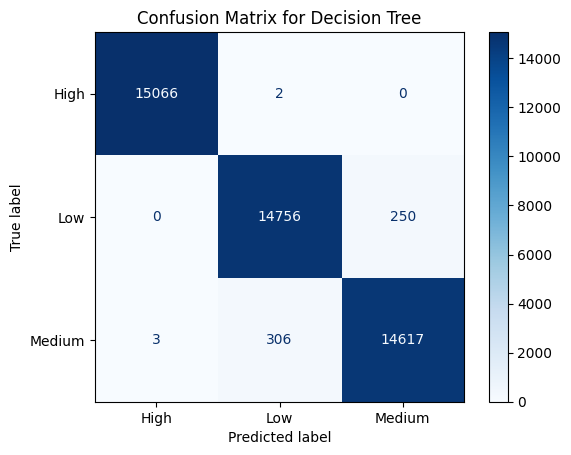

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix= cm , display_labels= pipe.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix for Decision Tree")
plt.savefig("cm.png")
plt.show()

In [17]:

dt= DecisionTreeClassifier (max_depth= 10)

pipe = Pipeline ([

     ("step1" , StandardScaler()),
    ("step2" , dt)
])


pipe.fit (x_train , y_train)

y_predict = pipe.predict (x_test)



print("\nTRAIN ",pipe.score(x_train,y_train))
print("TEST", pipe.score(x_test,y_test))

print("\nCONFUSION MATRIX\n", confusion_matrix(y_test , y_predict))

print("\nACCURACY SCORE", accuracy_score(y_test , y_predict))
print("PRECISION SCORE", precision_score(y_test , y_predict ,average=None))


TRAIN  0.9881055555555556
TEST 0.9875333333333334

CONFUSION MATRIX
 [[15066     2     0]
 [    0 14756   250]
 [    3   306 14617]]

ACCURACY SCORE 0.9875333333333334
PRECISION SCORE [0.99980092 0.9795539  0.98318423]


In [171]:
rf= RandomForestClassifier (n_estimators=300,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=25)

pipe = Pipeline ([

     ("step1" , StandardScaler()),
    ("step2" , rf)
])


pipe.fit (x_train , y_train)

y_predict = pipe.predict (x_test)


print("\nTRAIN ",pipe.score(x_train,y_train))
print("TEST", pipe.score(x_test,y_test))

print("\nCONFUSION MATRIX\n", confusion_matrix(y_test , y_predict))

print("\nACCURACY SCORE", accuracy_score(y_test , y_predict))
print("PRECISION SCORE", precision_score(y_test , y_predict ,average=None))


TRAIN  0.9996944444444444
TEST 0.9987555555555555

CONFUSION MATRIX
 [[14973    33     0]
 [   21 14903     2]
 [    0     0 15068]]

ACCURACY SCORE 0.9987555555555555
PRECISION SCORE [0.99859944 0.99779057 0.99986729]


In [172]:
et=  ExtraTreesClassifier (n_estimators=700,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15,
                             bootstrap=True)

pipe = Pipeline ([

     ("step1" , StandardScaler()),
    ("step2" , et)
])


pipe.fit (x_train , y_train)

y_predict = pipe.predict (x_test)


print("\nTRAIN ",pipe.score(x_train,y_train))
print("TEST", pipe.score(x_test,y_test))

print("\nCONFUSION MATRIX\n", confusion_matrix(y_test , y_predict))

print("\nACCURACY SCORE", accuracy_score(y_test , y_predict))
print("PRECISION SCORE", precision_score(y_test , y_predict ,average=None))


TRAIN  0.9988388888888889
TEST 0.9985333333333334

CONFUSION MATRIX
 [[14979    27     0]
 [   38 14887     1]
 [    0     0 15068]]

ACCURACY SCORE 0.9985333333333334
PRECISION SCORE [0.99746953 0.99818962 0.99993364]


In [173]:
ad=  AdaBoostClassifier (n_estimators=50,
                              learning_rate= 1)

pipe = Pipeline ([

     ("step1" , StandardScaler()),
    ("step2" , ad)
])


pipe.fit (x_train , y_train)

y_predict = pipe.predict (x_test)


print("\nTRAIN ",pipe.score(x_train,y_train))
print("TEST", pipe.score(x_test,y_test))

print("\nCONFUSION MATRIX\n", confusion_matrix(y_test , y_predict))

print("\nACCURACY SCORE", accuracy_score(y_test , y_predict))
print("PRECISION SCORE", precision_score(y_test , y_predict ,average=None))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.




TRAIN  0.7113222222222222
TEST 0.7128888888888889

CONFUSION MATRIX
 [[13222  1784     0]
 [10378  3967   581]
 [    0   177 14891]]

ACCURACY SCORE 0.7128888888888889
PRECISION SCORE [0.56025424 0.66919703 0.96244829]


In [174]:
gd=  GradientBoostingClassifier (n_estimators=200)

pipe = Pipeline ([

     ("step1" , StandardScaler()),
    ("step2" , gd)
])


pipe.fit (x_train , y_train)


y_predict = pipe.predict (x_test)


print("\nTRAIN ",pipe.score(x_train,y_train))
print("TEST", pipe.score(x_test,y_test))

print("\nCONFUSION MATRIX\n", confusion_matrix(y_test , y_predict))

print("\nACCURACY SCORE", accuracy_score(y_test , y_predict))
print("PRECISION SCORE", precision_score(y_test , y_predict ,average=None))


TRAIN  0.9979833333333333
TEST 0.9977777777777778

CONFUSION MATRIX
 [[14957    49     0]
 [   50 14875     1]
 [    0     0 15068]]

ACCURACY SCORE 0.9977777777777778
PRECISION SCORE [0.99666822 0.9967167  0.99993364]


In [175]:

svc = SVC (kernel= "rbf" , C = 100 )

pipe = Pipeline ([

    ("step1" , StandardScaler()),
    ("step2" , svc)
])


pipe.fit (x_train , y_train)

y_predict = pipe.predict (x_test)

print("\nTRAIN ",pipe.score(x_train,y_train))
print("TEST", pipe.score(x_test,y_test))

print("\nCONFUSION MATRIX\n", confusion_matrix(y_test , y_predict))

print("\nACCURACY SCORE", accuracy_score(y_test , y_predict))
print("PRECISION SCORE", precision_score(y_test , y_predict ,average=None))


TRAIN  0.9933222222222222
TEST 0.9923777777777778

CONFUSION MATRIX
 [[14866   140     0]
 [  197 14723     6]
 [    0     0 15068]]

ACCURACY SCORE 0.9923777777777778
PRECISION SCORE [0.9869216  0.99058064 0.99960196]


In [ ]:
svc = SVC (kernel= "rbf" , C = 100 , )

In [ ]:

import pickle

pickle.dump (dataset , open ("stress_dataset.pkl" , "wb"))
pickle.dump (pipe , open ("stress_ml_model.pkl" , "wb"))

In [ ]:

dt= DecisionTreeClassifier (max_depth= 10 ,
                           criterion="gini",
                           splitter="best",
                           min_samples_split=2,
                           min_samples_leaf=1,
                           max_features=None,
                           random_state=42)

In [ ]:
rf= RandomForestClassifier (n_estimators=300,
                              criterion="gini",
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=25,
                              bootstrap=True)

In [ ]:
et=  ExtraTreesClassifier (n_estimators=700,
                           criterion="gini",
                           random_state=3,
                           max_samples=0.5,
                           max_features=0.75,
                           max_depth=15,
                           bootstrap = True)

In [ ]:
ad=  AdaBoostClassifier (n_estimators = 50,
                         learning_rate = 1,
                         algorithm = "SAMME.R",
                         random_state = 42)

In [ ]:
gd=  GradientBoostingClassifier (n_estimators = 200,
                                loss = "log_loss",
                                tol = 0.0001,
                                min_samples_split = 2,
                                min_samples_leaf = 1,
                                random_state = 42
                                )

In [ ]:

svc = SVC (kernel= "rbf",
           C = 100,
           probability=False,
           random_state=42,
           degree= 3,
           class_weight=None)

In [ ]:
knn= KNeighborsClassifier (n_neighbors=8,
                          weights="uniform",
                          algorithm="auto",
                          metric="minkowski",
                          metric_params=None,
                          p=2)